# Seminární práce

In [2]:
import wfdb
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt

In [23]:
def load_data(path, from_sample = 0,to_sample=None):
    signals, fields = wfdb.rdsamp(path, sampfrom=from_sample, sampto=to_sample)
    ecg = signals[:, 0].flatten()
    return ecg, fields

def butter_highpass_filter(ecg, cutoff, fs, order=4):
    nyquist = fs/2
    normal_cutoff = cutoff / nyquist
    b, a = sig.butter(order, normal_cutoff, btype='high', analog=False)
    y = sig.filtfilt(b, a, ecg)
    return np.array(y)

def butter_lowpass_filter(ecg, cutoff, fs, order=4):
    nyquist = fs/2
    normal_cutoff = cutoff / nyquist
    b, a = sig.butter(order, normal_cutoff, btype='low', analog=False)
    y = sig.filtfilt(b, a, ecg)
    return np.array(y)

def mean_filter(ecg):
    return np.array(ecg - np.mean(ecg))

def std_filter(ecg):
    threshold = np.std(ecg) * 3
    ecg[ecg > threshold] = threshold
    return np.array(ecg)

def filtering(ecg, fs, lowcut=0.5, highcut=40):    
    ecg[ecg < 0] = 0  
    ecg = butter_highpass_filter(ecg, lowcut, fs)
    ecg = butter_lowpass_filter(ecg, highcut, fs)
    ecg = mean_filter(ecg)
    ecg = std_filter(ecg)
    return np.array(ecg)

def find_r_peaks(ecg, threshold=97):
    ecg_altered = ecg**3  
    threshold = np.percentile(ecg_altered, threshold)
    peaks, _ = sig.find_peaks(ecg_altered, height=threshold) 

    return np.array(peaks)

def count_BPM(ecg, peaks, fs, window_duration=60):
    signal_length = len(ecg) / fs  
    num_windows = int(signal_length / window_duration)  
    bpm = []
    time_stamps = []
    for i in range(num_windows):
        start_time = i * window_duration
        end_time = (i + 1) * window_duration
        start_index = int(start_time * fs)
        end_index = min(int(end_time * fs), len(ecg))

        peaks_in_window = [peak for peak in peaks if start_index <= peak < end_index]

        bpm_value = len(peaks_in_window) / window_duration * 60  
        bpm.append(bpm_value)
        time_stamps.append(start_time)

    return np.array(time_stamps), np.array(bpm)

def draw_ecg(ecg,fs, peaks=None, anomaly = None, rr = None, threshold = None, title = None):
    time_axis = np.arange(len(ecg)) / fs / 60

    plt.figure(figsize=(12, 5))
    plt.title(title)
    plt.plot(time_axis, ecg, label="EKG signál") 
    if peaks is not None:
        plt.scatter(time_axis[peaks],ecg[peaks], c='orange', label="R vrcholy")
    if anomaly is not None:
        plt.scatter(time_axis[anomaly],ecg[anomaly], c='red', label="Anomálie vrcholů")
    if threshold is not None:
        plt.axhline(y=threshold[0], color='darkblue', linestyle='--', label="Horní práh detekce vrcholů")
        plt.axhline(y=threshold[1], color='purple', linestyle='--', label="Spodní práh detekce vrcholů")
    if rr is not None:
        first_rr = True  
        for idx in rr:
            label = "Anomálie RR intervalů" if first_rr else ""
            plt.axvspan(time_axis[idx[0]], time_axis[idx[1]], color="red", alpha=0.4, label=label)
            first_rr = False
    plt.xlabel("Čas [min]")
    plt.ylabel("Amplituda")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

def draw_bpm_graph(time_stamps, bpm, title="Srdeční frekvence", normal_range=(60, 100)):
    plt.figure(figsize=(12, 5))

    time_axis = np.array(time_stamps) / 60  

    # Graf BPM
    plt.plot(time_axis, bpm, color='blue', linestyle='-', label="BPM")

    plt.fill_between(time_axis, normal_range[0], normal_range[1], color='green', alpha=0.2, label="Normální rozsah")

    # Popisky a legenda
    plt.xlabel("Čas [min]")
    plt.ylabel("BPM")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

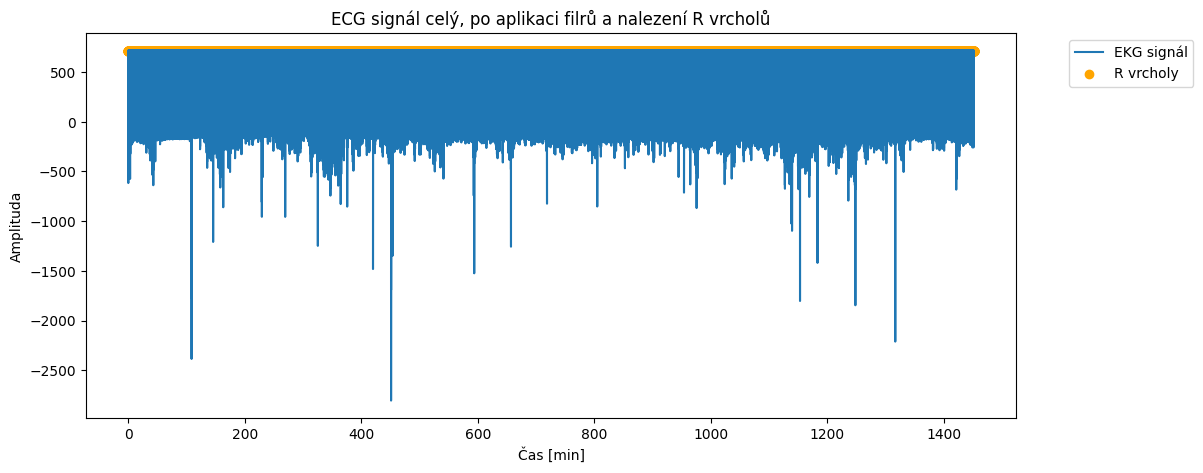

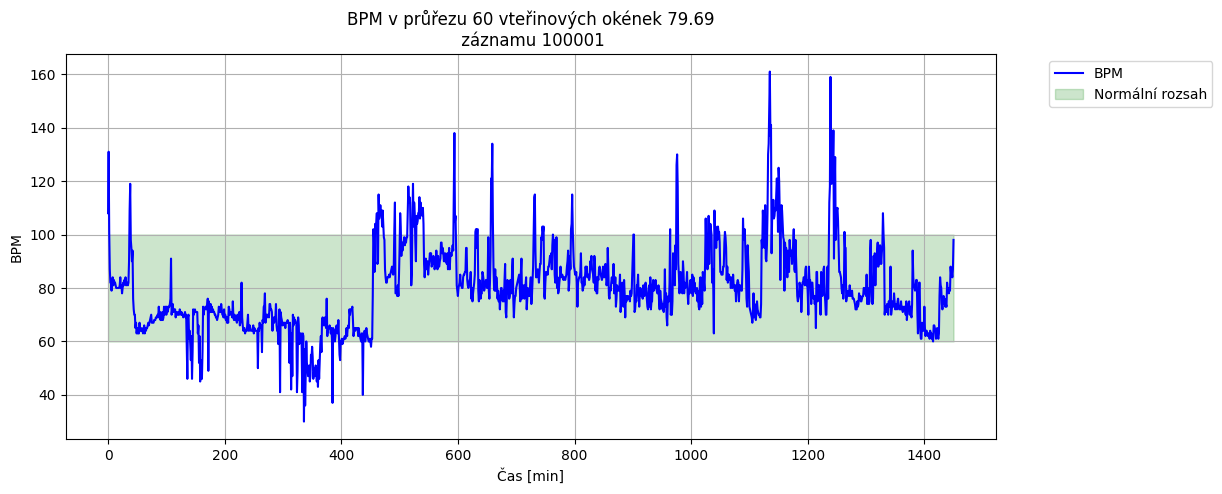

In [24]:
record = "100001"
path = f"./data_ecg/{record}/{record}_ECG"
ecg_signal, fields = load_data(path)
fs = fields["fs"]
ecg_signal_filtered = filtering(ecg_signal, fs)
peaks = find_r_peaks(ecg_signal_filtered)
draw_ecg(ecg_signal_filtered,fs, peaks, title="ECG signál celý, po aplikaci filrů a nalezení R vrcholů")

window_duration = 60
stamp, bpm = count_BPM(ecg_signal, peaks, fs, window_duration)
mean_bpm = np.round(np.mean(bpm), 2)
draw_bpm_graph(stamp, bpm, f"BPM v průřezu {window_duration} vteřinových okének {mean_bpm}\n záznamu {record}")

# Test

In [5]:
def test_file(my_peaks, anoted_peaks):
    anoted = len(anoted_peaks)
    my = len(my_peaks)
    detected = 0
    for peak in anoted_peaks:
        for my_peak in my_peaks:
            if abs(peak - my_peak) < 3:
                detected += 1
                break
    
    res = {
        "anoted": anoted,
        "my_peaks": my,
        "detected": detected,
        "missed": anoted - detected,
        "false positive": my - detected,
        "success": f"{np.round(detected / anoted * 100,2)} %"
    }
    return res

In [6]:
with open("./mit-bih-normal-sinus-rhythm-database-1.0.0/RECORDS", "r") as f:
    records = f.readlines()
records = [record.strip() for record in records]

results =[]
for record in records:
    path = f"./mit-bih-normal-sinus-rhythm-database-1.0.0/{record}"
    ecg_signal, fields = load_data(path, 0, 100000)
    fs = fields["fs"]
    ecg_signal_filtered = filtering(ecg_signal, fs)
    peaks = find_r_peaks(ecg_signal_filtered)
    true_peaks = wfdb.rdann(path, 'atr', sampfrom=0, sampto=100000).sample
    res = [record, test_file(peaks, true_peaks)]
    results.append(res)

print("Výsledky testování:")
print("Záznam | Anotované vrcholy | Nalezené vrcholy | Detekované vrcholy | Chyby | Falešné detekce | Úspěšnost")
print("-" * 90)
for res in results:
    print(f"{res[0]:<10} | {res[1]['anoted']:<13} | {res[1]['my_peaks']:<16} | {res[1]['detected']:<18} | {res[1]['missed']:<5} | {res[1]['false positive']:<15} | {res[1]['success']}")
print("-" * 90)
print("Celková úspěšnost: ", np.round(sum([float(res[1]['success'][:-2]) for res in results]) / len(results), 2), "%")

Výsledky testování:
Záznam | Anotované vrcholy | Nalezené vrcholy | Detekované vrcholy | Chyby | Falešné detekce | Úspěšnost
------------------------------------------------------------------------------------------
16265      | 1317          | 1304             | 1294               | 23    | 10              | 98.25 %
16272      | 997           | 1090             | 907                | 90    | 183             | 90.97 %
16273      | 1243          | 1233             | 1202               | 41    | 31              | 96.7 %
16420      | 1154          | 1149             | 1120               | 34    | 29              | 97.05 %
16483      | 1171          | 1181             | 749                | 422   | 432             | 63.96 %
16539      | 1095          | 1090             | 1085               | 10    | 5               | 99.09 %
16773      | 1391          | 991              | 958                | 433   | 33              | 68.87 %
16786      | 964           | 959              | 959             

# Anomaly detection

In [7]:
def anomaly_filter(ecg, fs, lowcut=0.5, highcut=40):
    ecg = butter_highpass_filter(ecg, lowcut, fs)
    ecg = butter_lowpass_filter(ecg, highcut, fs)

    return np.array(ecg)

def fit_filter(ecg, fs, lowcut=0.5, highcut=40):
    ecg = butter_highpass_filter(ecg, lowcut, fs)
    ecg = butter_lowpass_filter(ecg, highcut, fs)
    
    return np.array(ecg)

def mean_filter(ecg):
    return np.array(ecg - np.mean(ecg))

def peak_deviation(ecg, peaks, amplifier = 1):
    peak_values = ecg[peaks]
    thresholdup = np.mean(peak_values) + amplifier*np.std(peak_values)
    thresholddown = np.mean(peak_values) - amplifier*np.std(peak_values)
    anomalies = [peaks[i] for i in range(len(peak_values)) if peak_values[i] > thresholdup or peak_values[i] < thresholddown]
    
    return anomalies, thresholdup, thresholddown, len(anomalies)

def rr_deviation(peaks, fs, amplifier=1.5):
    rr_intervals = np.diff(peaks) / fs
    rr_mean = np.mean(rr_intervals)
    rr_std = np.std(rr_intervals) 
    threshold_high = rr_mean + amplifier * rr_std
    anomalies = [(peaks[i], peaks[i+1]) for i in range(len(rr_intervals)) if np.abs(rr_intervals[i]) > threshold_high]

    return anomalies, len(anomalies)    

def junk(ecg, fs, lowcut=0.5, highcut=40):
    ecg_filtered = fit_filter(ecg, fs, lowcut, highcut)
    ecg = ecg - ecg_filtered
    return(np.array(ecg))


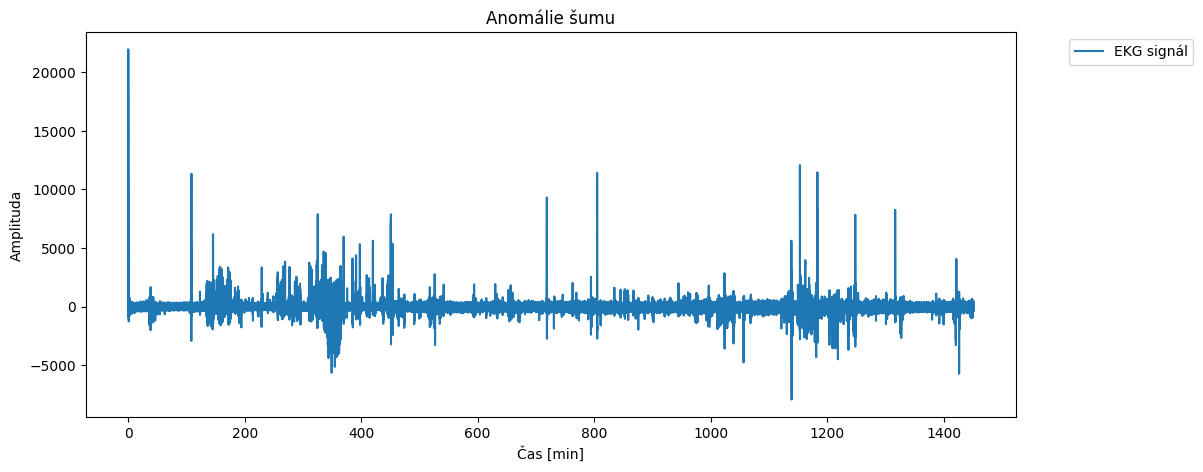

In [26]:
ecg, fields = load_data("./data_ecg/100001/100001_ECG")
fs = fields["fs"]
ecg_demonstration = ecg
samples = None
ecg_demonstration = ecg_demonstration[0:samples]
res = junk(ecg_demonstration, fs)
draw_ecg(res,fs,title="Anomálie šumu")

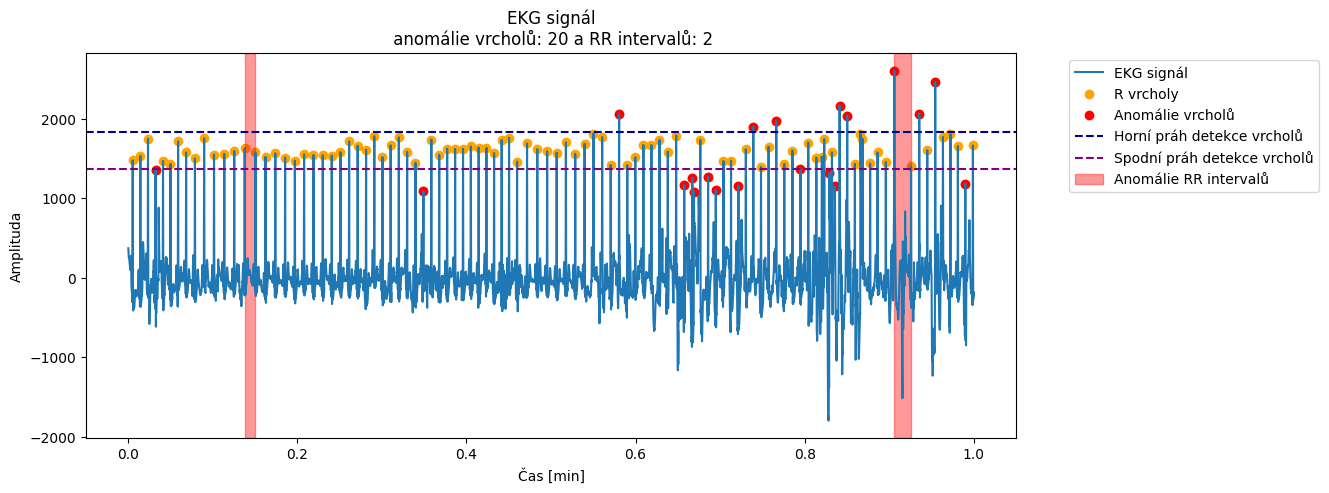

In [16]:
ecg, fields = load_data("./data_ecg/100001/100001_ECG")
fs = fields["fs"]
ecg_demonstration = fit_filter(ecg, fs)
samples = 60000*1
ecg_demonstration = ecg_demonstration[0:samples]
ecg = ecg[0:samples]
ecg_filtered = anomaly_filter(ecg, fs)

peaks = find_r_peaks(ecg_filtered)
anomaly, thresholdup, thresholddown, peak_dev_count = peak_deviation(ecg_filtered, peaks, 1)
threshold = [thresholdup, thresholddown]
rr, rr_dev_count= rr_deviation(peaks, fs)
draw_ecg(ecg_demonstration,fs = fs, peaks = peaks, anomaly = anomaly, rr = rr, threshold = threshold, title=f"EKG signál\n anomálie vrcholů: {peak_dev_count} a RR intervalů: {rr_dev_count}")